Scenariusz: Sieć sklepów “WroRetail” chce przewidywać sprzedaż. Surowe dane (data, produkt,
ilość) nie wystarczają. Potrzebujesz stworzyć bogate cechy czasowe i agregacyjne, które uchwycą
sezonowość i trendy.
Dane: Użyj danych z Kaggle Store Sales (Favorita) lub syntetycznych wroclaw.zip.

In [23]:
import numpy as np
import pandas as pd
import holidays

df = pd.read_csv("train.csv")

df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


(a) Cechy czasowe: Stwórz cechy z kolumny daty:
• Dzień tygodnia, miesiąc, kwartał, rok
• Weekend (sobota/niedziela)
• Dni do/od najbliższego święta
• Pora roku (wiosna/lato/jesień/zima)
Zwizualizuj sezonowość sprzedaży (tygodniową, miesięczną, roczną).

In [24]:
df["date"] = pd.to_datetime(df["date"])
df["dow"]     = df["date"].dt.dayofweek
df["month"]   = df["date"].dt.month 
df["quarter"] = df["date"].dt.quarter  
df["year"]    = df["date"].dt.year
df["is_weekend"] = (df["dow"] >= 5).astype(int)

def season_from_month(m):
    if m in (3,4,5):   return "spring"
    if m in (6,7,8):   return "summer"
    if m in (9,10,11): return "autumn"
    return "winter"

df["season"] = df["month"].map(season_from_month)

def add_holiday_distances(df, country="EC", date_col="date"):
    df = df.copy()

    d = pd.to_datetime(df[date_col]).dt.normalize()
    start = (d.min() - pd.Timedelta(days=366)).year
    end   = (d.max() + pd.Timedelta(days=366)).year

    hol = holidays.country_holidays(country, years=range(start, end + 1))

    hol_dates = pd.to_datetime(list(hol.keys())).normalize().sort_values().to_numpy()

    x = d.to_numpy() 

    idx = np.searchsorted(hol_dates, x, side="left")
    idx_next = np.clip(idx, 0, len(hol_dates) - 1)
    idx_prev = np.clip(idx - 1, 0, len(hol_dates) - 1)

    next_h = hol_dates[idx_next]
    prev_h = hol_dates[idx_prev]

    one_day = np.timedelta64(1, "D")
    df["days_until_holiday"] = ((next_h - x) / one_day).astype(int)
    df["days_since_holiday"] = ((x - prev_h) / one_day).astype(int)

    return df

df = add_holiday_distances(df, country="EC")

df.head()

,id,date,store_nbr,family,sales,onpromotion,dow,month,quarter,year,is_weekend,season,days_until_holiday,days_since_holiday
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,1,1,2013,0,winter,0,7
1,1,2013-01-01,1,BABY CARE,0.0,0,1,1,1,2013,0,winter,0,7
2,2,2013-01-01,1,BEAUTY,0.0,0,1,1,1,2013,0,winter,0,7
3,3,2013-01-01,1,BEVERAGES,0.0,0,1,1,1,2013,0,winter,0,7
4,4,2013-01-01,1,BOOKS,0.0,0,1,1,1,2013,0,winter,0,7


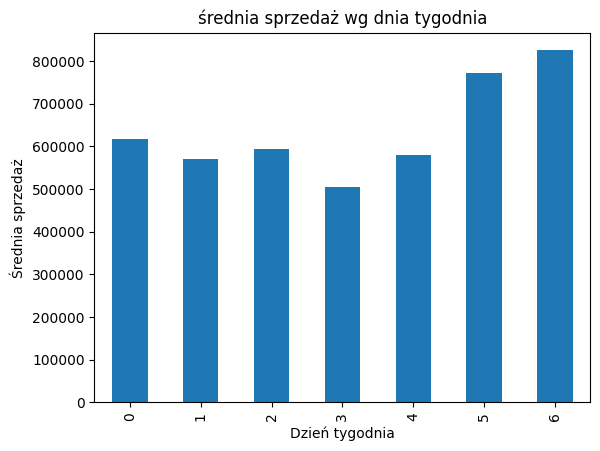

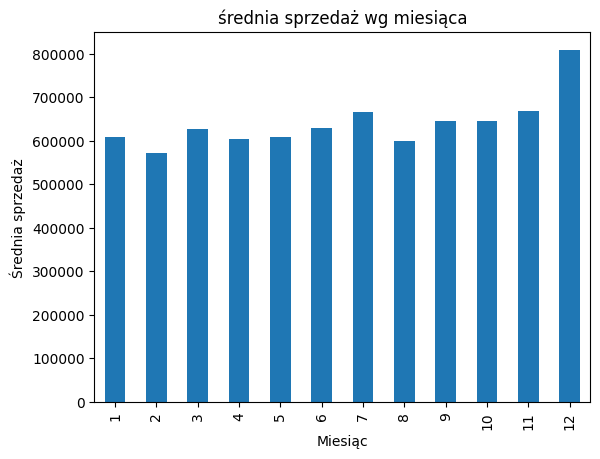

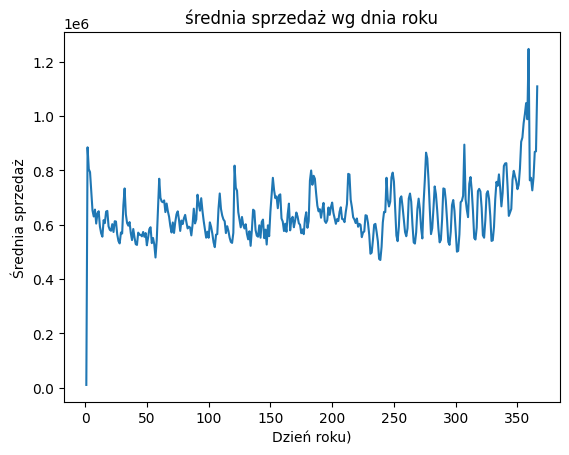

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df["date"] = pd.to_datetime(df["date"])

daily = df.groupby("date", as_index=False)["sales"].sum()

tmp = daily.copy()
tmp["dow"] = tmp["date"].dt.dayofweek 
week = tmp.groupby("dow")["sales"].mean()

plt.figure()
week.plot(kind="bar")
plt.title("średnia sprzedaż wg dnia tygodnia")
plt.xlabel("Dzień tygodnia")
plt.ylabel("Średnia sprzedaż")
plt.show()

tmp = daily.copy()
tmp["month"] = tmp["date"].dt.month
mon = tmp.groupby("month")["sales"].mean()

plt.figure()
mon.plot(kind="bar")
plt.title("średnia sprzedaż wg miesiąca")
plt.xlabel("Miesiąc")
plt.ylabel("Średnia sprzedaż")
plt.show()

tmp = daily.copy()
tmp["doy"] = tmp["date"].dt.dayofyear 
doy = tmp.groupby("doy")["sales"].mean()

plt.figure()
plt.plot(doy.index, doy.values)
plt.title("średnia sprzedaż wg dnia roku")
plt.xlabel("Dzień roku)")
plt.ylabel("Średnia sprzedaż")
plt.show()


In [26]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["store_nbr", "family", "date"])

g = df.groupby(["store_nbr", "family"])["sales"]

df["sales_lag_1"]  = g.shift(1)
df["sales_lag_7"]  = g.shift(7)
df["sales_lag_28"] = g.shift(28)

s = g.shift(1)

grp = [df["store_nbr"], df["family"]]

df["roll_mean_7"]  = s.groupby(grp).rolling(7,  min_periods=1).mean().reset_index(level=[0,1], drop=True)
df["roll_std_7"]   = s.groupby(grp).rolling(7,  min_periods=2).std().reset_index(level=[0,1], drop=True)

df["roll_mean_28"] = s.groupby(grp).rolling(28, min_periods=1).mean().reset_index(level=[0,1], drop=True)
df["roll_std_28"]  = s.groupby(grp).rolling(28, min_periods=2).std().reset_index(level=[0,1], drop=True)


In [27]:
fd = (df.groupby(["family","date"], as_index=False)["sales"].sum()
        .sort_values(["family","date"]))
g = fd.groupby("family")["sales"]
fd["prod_hist_mean"] = (g.cumsum() - fd["sales"]) / g.cumcount()
df = df.merge(
    fd[["family","date","prod_hist_mean"]],
    on=["family","date"], how="left"
)

sd = (df.groupby(["store_nbr","date"], as_index=False)["sales"].sum()
        .sort_values(["store_nbr","date"]))
g = sd.groupby("store_nbr")["sales"]
sd["store_hist_mean"] = (g.cumsum() - sd["sales"]) / g.cumcount()
df = df.merge(
    sd[["store_nbr","date","store_hist_mean"]],
    on=["store_nbr","date"], how="left"
)

fdd = (df.groupby(["family","dow","date"], as_index=False)["sales"].sum()
         .sort_values(["family","dow","date"]))
g = fdd.groupby(["family","dow"])["sales"]
fdd["family_dow_hist_mean"] = (g.cumsum() - fdd["sales"]) / g.cumcount()
df = df.merge(
    fdd[["family","dow","date","family_dow_hist_mean"]],
    on=["family","dow","date"], how="left"
)

df.tail()

,id,date,store_nbr,family,sales,onpromotion,dow,month,quarter,year,...,sales_lag_1,sales_lag_7,sales_lag_28,roll_mean_7,roll_std_7,roll_mean_28,roll_std_28,prod_hist_mean,store_hist_mean,family_dow_hist_mean
3000883,2993627,2017-08-11,54,SEAFOOD,0.0,0,4,8,3,2017,...,2.0,0.0,0.0,3.000000,4.281744,3.142857,2.606463,1197.184236,6552.133964,1397.946286
3000884,2995409,2017-08-12,54,SEAFOOD,1.0,1,5,8,3,2017,...,0.0,3.0,2.0,3.000000,4.281744,3.142857,2.606463,1197.229136,6553.301643,1386.168346
3000885,2997191,2017-08-13,54,SEAFOOD,2.0,0,6,8,3,2017,...,1.0,0.0,5.0,2.714286,4.347961,3.107143,2.629453,1197.128482,6554.840237,1522.275452
3000886,2998973,2017-08-14,54,SEAFOOD,0.0,0,0,8,3,2017,...,2.0,0.0,3.0,3.000000,4.203173,3.000000,2.610520,1197.081466,6559.413357,1084.646692
3000887,3000755,2017-08-15,54,SEAFOOD,3.0,0,1,8,3,2017,...,0.0,12.0,6.0,3.000000,4.203173,2.892857,2.671375,1196.946943,6562.576506,990.947303


In [29]:
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error
from lightgbm import LGBMRegressor

df["date"] = pd.to_datetime(df["date"])

VAL_DAYS = 28
cutoff = df["date"].max() - pd.Timedelta(days=VAL_DAYS)

train_mask = df["date"] <= cutoff
val_mask   = df["date"] > cutoff

for c in ["store_nbr", "family", "season"]:
    if c in df.columns:
        df[c] = df[c].astype("category")

target = "sales"


baseline_features = ["store_nbr", "family", "onpromotion", "dow", "month", "year"]


fe_features = [
    "store_nbr", "family", "onpromotion",
    "dow", "month", "quarter", "year", "is_weekend",
    "season",
    "days_until_holiday", "days_since_holiday",
    "sales_lag_1", "sales_lag_7", "sales_lag_28",
    "roll_mean_7", "roll_std_7", "roll_mean_28", "roll_std_28",
    "prod_hist_mean", "store_hist_mean", "family_dow_hist_mean",
    "store_family_hist_mean"
]

baseline_features = [c for c in baseline_features if c in df.columns]
fe_features       = [c for c in fe_features if c in df.columns]

def train_eval(features):
    X_train = df.loc[train_mask, features]
    y_train = df.loc[train_mask, target]
    X_val   = df.loc[val_mask, features]
    y_val   = df.loc[val_mask, target]

    model = LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[],
    )

    pred = model.predict(X_val)
    rmse = root_mean_squared_error(y_val, pred)
    return model, rmse

m0, rmse0 = train_eval(baseline_features)
m1, rmse1 = train_eval(fe_features)

print("Cutoff:", cutoff.date(), " Val days:", VAL_DAYS)
print(f"RMSE baseline: {rmse0:.4f}")
print(f"RMSE FE      : {rmse1:.4f}")
print(f"Poprawa: {rmse0 - rmse1:.4f}  ({(rmse0 - rmse1)/rmse0*100:.2f}%)")

imp = pd.DataFrame({
    "feature": fe_features,
    "importance": m1.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 20 feature importance:")
print(imp.head(20).to_string(index=False))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009010 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 316
[LightGBM] [Info] Number of data points in the train set: 2950992, number of used features: 6
[LightGBM] [Info] Start training from score 355.883067
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022546 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3035
[LightGBM] [Info] Number of data points in the train set: 2950992, number of used features: 21
[LightGBM] [Info] Start training from score 355.883067
Cutoff: 2017-07-18  Val days: 28
RMSE baseline: 261.4946
RMSE FE      : 196.4838
Poprawa: 65.0108  (24.86%)

Top 20 feature importance:
             feature  importance
  days_until_